# Классификация. Деревья решений

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import plot_tree
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.feature_selection import SequentialFeatureSelector

## Считать в `pandas.DataFrame` любой источник данных: CSV, JSON, Excel-файл, HTML-таблицу и т.п.

In [2]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Датасет и подготовка данных

### Привести описание датасета

Датасет содержит данные о пассажирах лайнера RMS Titanic, цель (целевой признак, таргет) — **прогнозирование выживания пассажира** при крушении судна.

| Признак | Описание | Единицы измерения / Возможные значения |
| --- | --- | --- |
| **PassengerId** | Уникальный идентификатор пассажира | Целое число (1–891) |
| **Survived** | Факт выживания (целевая переменная) | `0` — не выжил, `1` — выжил |
| **Pclass** | Класс билета (прокси для социально-экономического статуса) | `1` — первый класс (верхний), `2` — второй (средний), `3` — третий (нижний) |
| **Name** | Полное имя пассажира | Строка (включает титулы, фамилии, имена) |
| **Sex** | Пол пассажира | `male`, `female` |
| **Age** | Возраст пассажира | Годы (дробные для детей <1 года; оценки округляются до xx.5) |
| **SibSp** | Количество родственников-попутчиков: братьев, сестёр, супругов (включая сводных) | Целое неотрицательное число |
| **Parch** | Количество родителей или детей-попутчиков (мать, отец, дочь, сын, сводные); дети с няней имеют `Parch=0` | Целое неотрицательное число |
| **Ticket** | Номер билета | Строка (может содержать буквы, цифры, разделители) |
| **Fare** | Стоимость билета | Фунты стерлингов (£) |
| **Cabin** | Номер каюты | Строка (буква + номер); много пропущенных значений |
| **Embarked** | Порт посадки | `C` = Cherbourg (Шербур), `Q` = Queenstown (Квинстаун), `S` = Southampton (Саутгемптон) |

Целевой признак: `Survived`

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


### Осуществить предобработку данных (избавиться от `null`, убрать некоторые признаки и т.п.) &ndash; "подчистить данные"

#### Удаление бесполезных колонок

`PassengerId` - просто индекс, `Name` - уникальное имя (но его можно использовать для извлечения титулов)
`Ticket` - слишком много уникальных значений, сложно категоризировать без глубокого анализа

In [4]:
columns_to_drop = ['PassengerId', 'Ticket']
df.drop(columns=columns_to_drop, inplace=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    str    
 3   Sex       891 non-null    str    
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Fare      891 non-null    float64
 8   Cabin     204 non-null    str    
 9   Embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(4)
memory usage: 69.7 KB


#### Обработка пропусков

Age: заполним медианой (или средним) в зависимости от Pclass и Sex для точности

In [5]:
df['Age'] = df.groupby(['Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.median()))

Cabin: слишком много пропусков

Создадим признак "Есть ли каюта" (была каюта или нет), так как это может коррелировать с выживанием

In [6]:
df['Has_Cabin'] = df['Cabin'].apply(lambda x: 0 if pd.isna(x) else 1)
df.drop(columns=['Cabin'], inplace=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Survived   891 non-null    int64  
 1   Pclass     891 non-null    int64  
 2   Name       891 non-null    str    
 3   Sex        891 non-null    str    
 4   Age        891 non-null    float64
 5   SibSp      891 non-null    int64  
 6   Parch      891 non-null    int64  
 7   Fare       891 non-null    float64
 8   Embarked   889 non-null    str    
 9   Has_Cabin  891 non-null    int64  
dtypes: float64(2), int64(5), str(3)
memory usage: 69.7 KB


Embarked: всего 2 пропуска, заполним модой (самым частым значением)

In [7]:
embarked_mode = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(embarked_mode)

#### Создание новых признаков (Feature Engineering)

Title из Name

In [8]:
df['Title'] = df['Name'].apply(lambda name: name.split(',')[1].split('.')[0].strip())
df['Title'].value_counts()

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

Объединим редкие титулы

In [9]:
rare_titles = ['Dr', 'Rev', 'Col', 'Major', 'Capt', 'Sir', 'Lady', 
                'the Countess', 'Jonkheer', 'Don']
df['Title'] = df['Title'].replace(rare_titles, 'Rare')
df['Title'] = df['Title'].replace(['Mlle', 'Ms'], 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')
df['Title'].value_counts()

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

Удалим Name

In [10]:
df.drop(columns=['Name'], inplace=True)

Создадим признак "Размер семьи"

In [11]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

Создадим признак "Одинокий"

In [12]:
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Sex         891 non-null    str    
 3   Age         891 non-null    float64
 4   SibSp       891 non-null    int64  
 5   Parch       891 non-null    int64  
 6   Fare        891 non-null    float64
 7   Embarked    891 non-null    str    
 8   Has_Cabin   891 non-null    int64  
 9   Title       891 non-null    str    
 10  FamilySize  891 non-null    int64  
 11  IsAlone     891 non-null    int64  
dtypes: float64(2), int64(7), str(3)
memory usage: 83.7 KB


### Закодировать категориальные признаки при необходимости

Кодирование бинарного признака `Sex`

In [14]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

One-Hot Encoding для `Title` и `Embarked`

In [15]:
df = pd.get_dummies(df, columns=['Title', 'Embarked'])

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Survived      891 non-null    int64  
 1   Pclass        891 non-null    int64  
 2   Sex           891 non-null    int64  
 3   Age           891 non-null    float64
 4   SibSp         891 non-null    int64  
 5   Parch         891 non-null    int64  
 6   Fare          891 non-null    float64
 7   Has_Cabin     891 non-null    int64  
 8   FamilySize    891 non-null    int64  
 9   IsAlone       891 non-null    int64  
 10  Title_Master  891 non-null    bool   
 11  Title_Miss    891 non-null    bool   
 12  Title_Mr      891 non-null    bool   
 13  Title_Mrs     891 non-null    bool   
 14  Title_Rare    891 non-null    bool   
 15  Embarked_C    891 non-null    bool   
 16  Embarked_Q    891 non-null    bool   
 17  Embarked_S    891 non-null    bool   
dtypes: bool(8), float64(2), int64(8)
memory u

### Разбить выборку на обучающую и тестовую.

> Далее используем обучающую выборку, в том числе для метрик.

In [17]:
X = df.drop(columns=['Survived'])
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Нормализовать данные

In [18]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### При наличии дисбаланса классов снизить дисбаланс классов

In [19]:
y.value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

Дисбаланс некритичный

## Дерево решений

### С использованием `GridSearchCV` осуществить подбор гиперпараметра `DecisionTreeClassifier`

(как минимум `max_depth`, `max_features`, другие параметры &ndash; по желанию.)

In [20]:
dt = DecisionTreeClassifier(random_state=42)

param_grid = {
    'max_depth': [3, 5, 7, 10, 12, 15],
    'max_features': [3, 5, 7, 10, 12, 15, 18],
    'min_samples_leaf': [1, 3, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10, 15, 20]
}

grid_search = GridSearchCV(dt, param_grid, cv=5, n_jobs=-1)
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'max_features': [3, 5, ...], 'min_samples_leaf': [1, 3, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter 

### Вывести значения гиперпараметра и метрик для наилучшей модели `DecisionTreeClassifier` ($accuracy$, $precision$, $recall$, $\textit{f-measure}$)

In [21]:
best_model_dt = grid_search.best_estimator_
y_pred = best_model_dt.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred)
prec_dt = precision_score(y_test, y_pred)
rec_dt = recall_score(y_test, y_pred)
f1_dt = f1_score(y_test, y_pred)

print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Лучший score на валидации: {grid_search.best_score_}\n")
print(f"Accuracy: {acc_dt:.4f}")
print(f"Precision: {prec_dt:.4f}")
print(f"Recall: {rec_dt:.4f}")
print(f"F1-score: {f1_dt:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Лучшие параметры: {'max_depth': 3, 'max_features': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Лучший score на валидации: 0.8300108342361863

Accuracy: 0.8212
Precision: 0.8088
Recall: 0.7432
F1-score: 0.7746

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.88      0.85       105
           1       0.81      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



### Для полученного наилучшего дерева вывести `feature_importances`, отсортировать их по убыванию

In [22]:
importance_df = pd.DataFrame({
    'feature': X.columns.tolist(),
    'importance': best_model_dt.feature_importances_
}).sort_values('importance', ascending=False)
importance_df

,feature,importance
1,Sex,0.613117
7,FamilySize,0.182923
0,Pclass,0.095926
9,Title_Master,0.057256
6,Has_Cabin,0.050778
4,Parch,0.000000
3,SibSp,0.000000
5,Fare,0.000000
2,Age,0.000000
8,IsAlone,0.000000


### Осуществить фильтрацию признаков

Оставим только важные признаки

In [23]:
filtered_features = importance_df[importance_df['importance'] > 0]
filtered_features

,feature,importance
1,Sex,0.613117
7,FamilySize,0.182923
0,Pclass,0.095926
9,Title_Master,0.057256
6,Has_Cabin,0.050778


In [24]:
selected_indices_dt = filtered_features.index.tolist()
X_train_f = X_train[:, selected_indices_dt]
X_test_f = X_test[:, selected_indices_dt]

### Подобрать лучшую модель с использованием `GridSearchCV` на обучающей выборке с отфильтрованными признаками

In [25]:
dt = DecisionTreeClassifier(random_state=42)

# Сетка параметров
param_grid = {
    'max_depth': range(2, 10),
    'max_features': range(1, 5),
    'min_samples_leaf': [1, 2, 3, 5, 7, 10, 12, 15, 20],
    'min_samples_split': [2, 3, 4, 5, 7, 10, 15, 20]
}

grid_search = GridSearchCV(dt, param_grid, cv=5, n_jobs=-1)
grid_search.fit(X_train_f, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': range(2, 10), 'max_features': range(1, 5), 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 3, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter

### Вывести полученные гиперпараметры лучшей модели

In [26]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_f)

acc_dt_f = accuracy_score(y_test, y_pred)
prec_dt_f = precision_score(y_test, y_pred)
rec_dt_f = recall_score(y_test, y_pred)
f1_dt_f = f1_score(y_test, y_pred)

print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Лучший score на валидации: {grid_search.best_score_}\n")
print(f"Accuracy: {acc_dt_f:.4f}")
print(f"Precision: {prec_dt_f:.4f}")
print(f"Recall: {rec_dt_f:.4f}")
print(f"F1-score: {f1_dt_f:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Лучшие параметры: {'max_depth': 5, 'max_features': 4, 'min_samples_leaf': 2, 'min_samples_split': 7}
Лучший score на валидации: 0.8356347877474637

Accuracy: 0.8268
Precision: 0.8116
Recall: 0.7568
F1-score: 0.7832

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.88      0.86       105
           1       0.81      0.76      0.78        74

    accuracy                           0.83       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



### Сравнить метрики до и после фильтрации признаков лучших моделей

In [27]:
pd.DataFrame({
    'Метрика': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'До': [acc_dt, prec_dt, rec_dt, f1_dt],
    'После': [acc_dt_f, prec_dt_f, rec_dt_f, f1_dt_f],
    'Разница': [
        acc_dt_f - acc_dt,
        prec_dt_f - prec_dt,
        rec_dt_f - rec_dt,
        f1_dt_f - f1_dt
    ]
}).round(4)

,Метрика,До,После,Разница
0,Accuracy,0.8212,0.8268,0.0056
1,Precision,0.8088,0.8116,0.0028
2,Recall,0.7432,0.7568,0.0135
3,F1-score,0.7746,0.7832,0.0086


Фильтрация признаков с 18 до 5 наиболее важных не только не ухудшила качество модели, но и привела к небольшому улучшению всех метрик: точность (Accuracy) выросла на 0.56%, precision на 0.28%, recall на 1.35%, а F1-score на 0.86%. Особенно важно улучшение recall (способности модели находить выживших), которое увеличилось наиболее существенно. Таким образом, удалось создать более простую и интерпретируемую модель с меньшим количеством признаков, которая при этом показывает даже лучшие результаты, чем исходная, что подтверждает эффективность проведенного отбора признаков.

## Случайный лес

### Построить случайный лес (`RandomForestClassifier`), c использованием `GridSearchCV` осуществить подбор гиперпараметра

In [28]:
rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 7, 10, 12, 15],
    'max_features': [3, 5, 7, 10, 12, 15, 18]
}

grid_search1 = GridSearchCV(rf, param_grid, cv=5, n_jobs=-1)
grid_search1.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'max_features': [3, 5, ...], 'n_estimators': [50, 100]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score 

### Вывести полученные гиперпараметры лучшей модели случайного леса

In [29]:
grid_search1.best_params_, grid_search1.best_score_

({'max_depth': 5, 'max_features': 12, 'n_estimators': 100},
 np.float64(0.8370432384516893))

### Осуществить фильтрацию признаков

In [30]:
importance_df = pd.DataFrame({
    'feature': X.columns.tolist(),
    'importance': grid_search1.best_estimator_.feature_importances_
}).sort_values('importance', ascending=False)
importance_df

,feature,importance
11,Title_Mr,0.251938
1,Sex,0.235723
5,Fare,0.119440
0,Pclass,0.113670
2,Age,0.083732
7,FamilySize,0.062900
6,Has_Cabin,0.034557
13,Title_Rare,0.020235
3,SibSp,0.019838
12,Title_Mrs,0.013374


In [31]:
filtered_features = importance_df[importance_df['importance'] >importance_df['importance'].median()]
filtered_features

,feature,importance
11,Title_Mr,0.251938
1,Sex,0.235723
5,Fare,0.119440
0,Pclass,0.113670
2,Age,0.083732
7,FamilySize,0.062900
6,Has_Cabin,0.034557
13,Title_Rare,0.020235


In [32]:
selected_indices_rf = filtered_features.index.tolist()
X_train_f = X_train[:, selected_indices_rf]
X_test_f = X_test[:, selected_indices_rf]

### Подобрать лучшую модель с использованием `GridSearchCV` на обучающей выборке с отфильтрованными признаками

In [33]:
rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': range(2, 15),
    'max_features': range(1, 8)
}

grid_search2 = GridSearchCV(rf, param_grid, cv=5, n_jobs=-1)
grid_search2.fit(X_train_f, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': range(2, 15), 'max_features': range(1, 8), 'n_estimators': [50, 100]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score

### Вывести полученные гиперпараметры лучшей модели случайного леса

In [34]:
grid_search2.best_params_, grid_search2.best_score_

({'max_depth': 7, 'max_features': 4, 'n_estimators': 100},
 np.float64(0.8370530877573131))

### Сравнить метрики до и после фильтрации признаков лучших моделей

In [35]:
y_pred = grid_search1.best_estimator_.predict(X_test)
y_pred_f = grid_search2.best_estimator_.predict(X_test_f)

acc_rf = accuracy_score(y_test, y_pred)
prec_rf = precision_score(y_test, y_pred)
rec_rf = recall_score(y_test, y_pred)
f1_rf = f1_score(y_test, y_pred)

acc_rf_f = accuracy_score(y_test, y_pred_f)
prec_rf_f = precision_score(y_test, y_pred_f)
rec_rf_f = recall_score(y_test, y_pred_f)
f1_rf_f = f1_score(y_test, y_pred_f)

pd.DataFrame({
    'Метрика': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'До': [acc_rf, prec_rf, rec_rf, f1_rf],
    'После': [acc_rf_f, prec_rf_f, rec_rf_f, f1_rf_f],
    'Разница': [
        acc_rf_f - acc_rf,
        prec_rf_f - prec_rf,
        rec_rf_f - rec_rf,
        f1_rf_f - f1_rf
    ]
}).round(4)

,Метрика,До,После,Разница
0,Accuracy,0.8156,0.8268,0.0112
1,Precision,0.8154,0.8308,0.0154
2,Recall,0.7162,0.7297,0.0135
3,F1-score,0.7626,0.7770,0.0144


Фильтрация признаков также оказалась эффективной для модели случайного леса, приведя к заметному улучшению всех ключевых метрик. Точность (Accuracy) выросла на 1.12%, precision увеличилась на 1.54%, recall — на 1.35%, а итоговый F1-score повысился на 1.44%. Интересно, что фильтрация сильнее повлияла на случайный лес, чем на дерево решений: прирост метрик здесь более выражен (особенно precision и F1-score), что говорит о том, что устранение зашумляющих признаков помогло случайному лесу лучше обобщать закономерности и делать более уверенные предсказания.

## Метод ближайших соседей

### С использованием `GridSearchCV` осуществить подбор гиперпараметра `KNeighborsClassifier` (`n_neighbors`)

In [36]:
grid_search = GridSearchCV(
    KNeighborsClassifier(),
    {'n_neighbors': range(1, 21)},
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': range(1, 21)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter ind

### Вывести значения гиперпараметра и метрик для наилучшей модели

In [37]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

acc_knn = accuracy_score(y_test, y_pred)
prec_knn = precision_score(y_test, y_pred)
rec_knn = recall_score(y_test, y_pred)
f1_knn = f1_score(y_test, y_pred)

print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Лучший score на валидации: {grid_search.best_score_}\n")
print(f"Accuracy: {acc_knn:.4f}")
print(f"Precision: {prec_knn:.4f}")
print(f"Recall: {rec_knn:.4f}")
print(f"F1-score: {f1_knn:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Лучшие параметры: {'n_neighbors': 12}
Лучший score на валидации: 0.8314389835516597

Accuracy: 0.8212
Precision: 0.8281
Recall: 0.7162
F1-score: 0.7681

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.90      0.85       105
           1       0.83      0.72      0.77        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



### Осуществить фильтрацию признаков

In [38]:
knn_s = KNeighborsClassifier(n_neighbors=12)
sfs = SequentialFeatureSelector(knn_s, direction='forward', n_features_to_select='auto', cv=5)

sfs.fit(X_train, y_train)
X_train_f = sfs.transform(X_train)
X_test_f = sfs.transform(X_test)

print(f"Осталось признаков: {sfs.n_features_to_select_}")

Осталось признаков: 8


Сохраним индексы отфильтрованных признаков:

In [39]:
selected_indices_knn = sfs.get_support(indices=True)

### Подобрать лучшую модель с использованием `GridSearchCV` на обучающей выборке с отфильтрованными признаками

In [40]:
grid_search = GridSearchCV(
    KNeighborsClassifier(),
    {'n_neighbors': range(1, 21)},
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train_f, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': range(1, 21)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter ind

### Вывести полученные гиперпараметры лучшей модели KNN

In [41]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_f)

acc_knn_f = accuracy_score(y_test, y_pred)
prec_knn_f = precision_score(y_test, y_pred)
rec_knn_f = recall_score(y_test, y_pred)
f1_knn_f = f1_score(y_test, y_pred)

print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Лучший score на валидации: {grid_search.best_score_}\n")
print(f"Accuracy: {acc_knn_f:.4f}")
print(f"Precision: {prec_knn_f:.4f}")
print(f"Recall: {rec_knn_f:.4f}")
print(f"F1-score: {f1_knn_f:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Лучшие параметры: {'n_neighbors': 9}
Лучший score на валидации: 0.8286220821432089

Accuracy: 0.8212
Precision: 0.8000
Recall: 0.7568
F1-score: 0.7778

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.87      0.85       105
           1       0.80      0.76      0.78        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



### Сравнить метрики до и после фильтрации признаков

In [42]:
pd.DataFrame({
    'Метрика': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'До': [acc_knn, prec_knn, rec_knn, f1_knn],
    'После': [acc_knn_f, prec_knn_f, rec_knn_f, f1_knn_f],
    'Разница': [
        acc_knn_f - acc_knn,
        prec_knn_f - prec_knn,
        rec_knn_f - rec_knn,
        f1_knn_f - f1_knn
    ]
}).round(4)

,Метрика,До,После,Разница
0,Accuracy,0.8212,0.8212,0.0000
1,Precision,0.8281,0.8000,-0.0281
2,Recall,0.7162,0.7568,0.0405
3,F1-score,0.7681,0.7778,0.0097


Фильтрация признаков привела к интересному компромиссу для модели KNN: общая точность (Accuracy) осталась неизменной (82.12%), однако внутренняя структура ошибок модели изменилась. Наблюдается классическая дилемма смещения и дисперсии — recall (полнота) вырос на 4.05% (модель стала лучше находить выживших), но заплатила за это снижением precision (точности) на 2.81% (участились ложные срабатывания). В итоге F1-score (гармоническое среднее) все же вырос на 0.97%, что позволяет считать фильтрацию полезной — модель стала более сбалансированной и лучше справляется с поиском выживших пассажиров, хотя и ценой некоторого увеличения ложных тревог.

 ## Построение моделей для набора отфильтрованных признаков
 
 Если наблюдается улучшение метрик после фильтрации признаков хотя бы для одной из моделей, то для набора отфильтрованных признаков (пересечение множеств отфильтрованных признаков каждой модели или объединение множеств &ndash; не особо важно, главное описать, каким образом получен новый subset данных) заново построить наилучшие модели `KNeighborsClassifier`, `DecisionTreeClassifier`, `RandomForestClassifier`, сравнить модели в пункте 7 на одинаковом полученном наборе отфильтрованных признаков. Иначе &ndash; пропустить этот пункт.

Индексы отобранных признаков

In [43]:
print(f"DT({len(selected_indices_dt)}):  {selected_indices_dt}")
print(f"RF({len(selected_indices_rf)}):  {selected_indices_rf}")
print(f"KNN({len(selected_indices_knn)}): {selected_indices_knn}")

DT(5):  [1, 7, 0, 9, 6]
RF(8):  [11, 1, 5, 0, 2, 7, 6, 13]
KNN(8): [ 1  3  7  8  9 11 12 14]


Объединим отобранные признаки

In [44]:
union_indices = sorted(list(
    set(selected_indices_dt) | 
    set(selected_indices_rf) | 
    set(selected_indices_knn)
))

union_indices = [int(i) for i in union_indices]
print(f"{len(union_indices)} признаков:")
print(union_indices)

13 признаков:
[0, 1, 2, 3, 5, 6, 7, 8, 9, 11, 12, 13, 14]


фильтрация

In [45]:
X_train_sel = X_train[:, union_indices]
X_test_sel = X_test[:, union_indices]

Построение наилучших моделей

In [46]:
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    {
        'max_depth': range(2, 15),
        'max_features': range(1, 13),
        'min_samples_leaf': [1, 2, 3, 5, 7, 10, 12, 15, 20],
        'min_samples_split': [2, 3, 4, 5, 7, 10, 15, 20]
    },
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
dt_grid.fit(X_train_sel, y_train)
print(f"Лучшие параметры: {dt_grid.best_params_}")
print(f"Лучший score: {dt_grid.best_score_}")

Лучшие параметры: {'max_depth': 9, 'max_features': 8, 'min_samples_leaf': 1, 'min_samples_split': 20}
Лучший score: 0.8328474342558849


In [47]:
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    {
        'n_estimators': [50, 100],
        'max_depth': range(2, 15),
        'max_features': range(2, 13)
    },
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
rf_grid.fit(X_train_sel, y_train)
print(f"Лучшие параметры: {rf_grid.best_params_}")
print(f"Лучший score: {rf_grid.best_score_}")

Лучшие параметры: {'max_depth': 8, 'max_features': 5, 'n_estimators': 100}
Лучший score: 0.8384713877671623


In [48]:
knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    {'n_neighbors': range(1, 21)},
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
knn_grid.fit(X_train_sel, y_train)
print(f"Лучшие параметры: {knn_grid.best_params_}")
print(f"Лучший score: {knn_grid.best_score_}")

Лучшие параметры: {'n_neighbors': 13}
Лучший score: 0.8272234807446075


Список лучших моделей

In [49]:
best_models = {
    'KNN': knn_grid.best_estimator_,
    'DT': dt_grid.best_estimator_,
    'RF': rf_grid.best_estimator_
}

## Оценка качества построенных моделей

### Визуализировать любое полученное дерево решений

> Для вывода названий признаков в граф необходимо задать значение аргумента `feature_names` в `sklearn.tree.export_graphviz`, для вывода названий классов &ndash; `class_names` (перед кодированием целевого признака можно сохранить названия в отдельный массив).

Воспользуюсь `sklearn.tree.plot_tree`

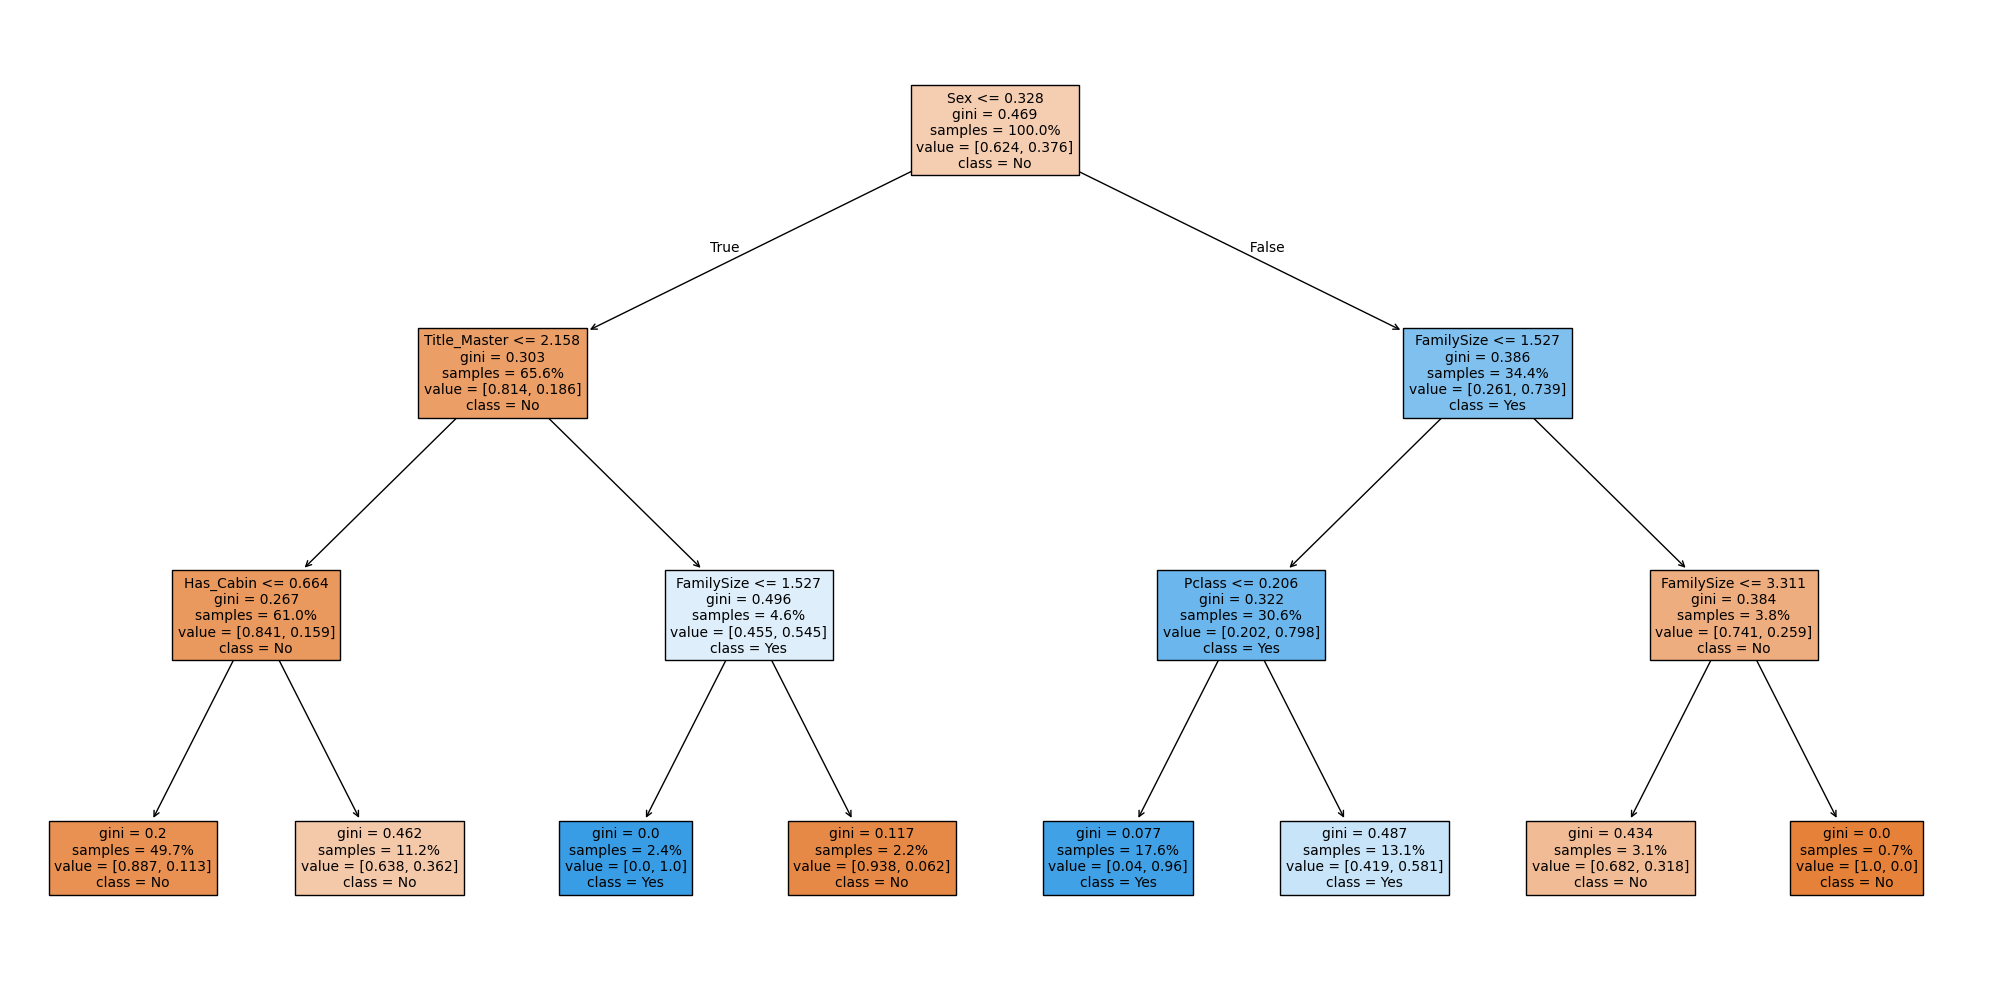

In [50]:
class_names = ['No', 'Yes']

plt.figure(figsize=(20, 10))
plot_tree(
    best_model_dt,
    feature_names=X.columns.tolist(),
    class_names=class_names,
    filled=True,
    fontsize=10,
    proportion=True
)

plt.tight_layout()
plt.show()

### Сравнить лучшие модели `KNeighborsClassifier`, `DecisionTreeClassifier`, `RandomForestClassifier` на **тестовой выборке**. Привести значения метрик $accuracy$, $precision$, $recall$, $\textit{f-measure}$

In [51]:
results_list = []

for name, model in best_models.items():
    model.fit(X_train_sel, y_train)
    y_pred = model.predict(X_test_sel)
    
    metrics = {
        'Модель': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1_score': f1_score(y_test, y_pred)
    }
    results_list.append(metrics)

pd.DataFrame(results_list)

,Модель,Accuracy,Precision,Recall,F1_score
0,KNN,0.815642,0.805970,0.729730,0.765957
1,DT,0.798883,0.771429,0.729730,0.750000
2,RF,0.821229,0.808824,0.743243,0.774648


Сравнение трех лучших моделей показывает, что случайный лес демонстрирует наилучшие результаты по большинству метрик: он лидирует по точности (Accuracy 82.12%), precision (80.88%), recall (74.32%) и F1-score (77.46%), что делает его наиболее сбалансированной и эффективной моделью для предсказания выживаемости на Титанике. KNN занимает промежуточное положение, немного уступая случайному лесу, но с сопоставимыми показателями. Дерево решений показывает самые скромные результаты, что объясняется его склонностью к переобучению и меньшей обобщающей способностью по сравнению с ансамблевым методом.